This is firs assignment (out of three). 

Submission guideline:

- Total point- 100 

- Attend all questions.

- Upload a zip/rar file containing the following:

    - MAS512_assignment1_gr#.py or MAS512_assignment1_gr#.ipynb. These files should be error free.

    - Each questions should be done in a cell, such that when I run the cell - I get the outputs.
    
    - MAS512_assignment1_gr#.ppt explaining the objective, method and results of each questions. 
    
    - Make   the presentation clear, readable, precise and attractive.

- Each group will be given 10 min to present the assignment followed by 5 minutes of Q/A. The presentation takes place in Lab, and all students are expected to attend peer's presentation

- Assignment is graded based on problem solving skills, work break down, algorithms, code, powerpoint and presentation

- Students are expected to solve the problem themselves.

- You can use LLM generative models as 'help', understand the working and algorithm, modify and use them.

- Be specific and precise when you write code, make powerpoint and present assignment

# **Q1. Object detection and depth estimation                             20+5+20 = 45 points**
 Use L515 camera in Lab to acquire rgb video and depth video (e.g. 30 s) of swinging load in lab (rgb_train_val_swingingload.avi; depth_train_val_swingingload.avi). Extract each frames from rgb video. Use the extracted images to train and validate YOLO model (save as YOLO_swinging_load.pt). Record test_swingingload.avi (e.g. 5 s). Extract frames and use them as test data set. Test your YOLO model (YOLO_swinging_load.pt) on this test data set.

(a) Show the performance of your model on test data set by plotting relevant KPIs.

(b) Sample five random images from test data video (test_swingingload.avi). Find the center, and coordinates of bounding box. Display them on the each test image.

(c) realsense_acq.ipynb contains code that streams, rgb, and depth video. Based on this code, extract the frames from depth_train_val_swingingload.avi. Each pixel in each frame consists of depth information of corresponding rgb images. As described in Q1.b find the center of bounding box of ALL frames in  test video (test_swingingload.avi). Display its center and corresponding depth.


References: Use Ultralytics framework for help - https://docs.ultralytics.com/tasks/detect
Realsense - https://dev.realsenseai.com/sdk-2-0-code-samples-wrappers-and-languages/opencv/ 

Data acquisition: realsense_acq.ipynb contains the code to acquire RGB and Depth data from L515.
 
Cell 1: Streams RGB and Depth data

Cell 2: Streams RGB and Depth data, and saves the following:
- session_date_time e.g. session_20260914_1354
  - /color_video. Contains colour RGB video
  - /depth_video. Contains depth video video
  - /depth_raw. Contains raw depth value
  - /depth_scale_json. Contains scaling factor. multiply this scaling factor with raw scale to obtain true depth in meter
  -/rgb_frames. Contains RGB frames that you can use for labeling and object detection


Ultralytics 8.4.158  Python-3.10.11 torch-2.14.0+cpu CPU (AMD Ryzen 5 7535U with Radeon Graphics)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 986.7280.2 MB/s, size: 509.8 KB)
val: Scanning C:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\data_load_detection_YOLO\test\labels.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.4it/s 13.9s0.7s
                   all        300        300          1          1      0.995      0.912
Speed: 1.0ms preprocess, 33.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to C:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\MAS512-Assignment1\Assignment 1\runs\detect\test_metrics


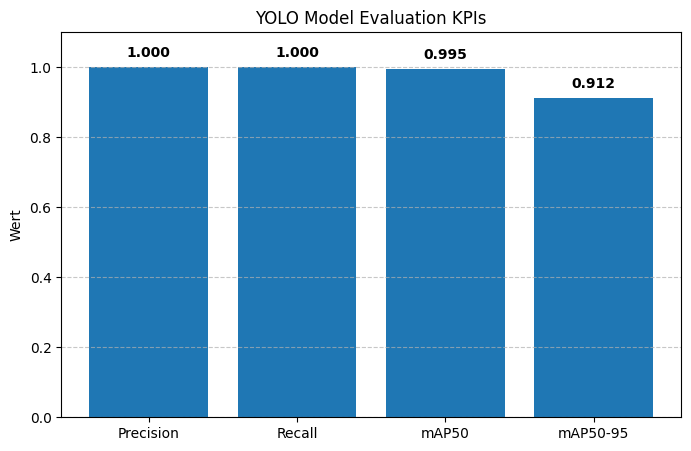

In [ ]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path("c:/Users/quapu/Desktop/MT/9_Semester/MAS_512_ComputerVision/512_Repos")
yaml_path = base_dir / "testData.yaml"
model_path = base_dir / "MAS512-Assignment1" / "Assignment 1" / "best.pt"

model = YOLO(str(model_path))

# Auf den Testdaten evaluieren (split='test' in data.yaml definieren)
metrics = model.val(data=str(yaml_path), split="test", name="test_metrics", exist_ok=True)

kpis = {
    "Precision": metrics.box.mp,
    "Recall": metrics.box.mr,
    "mAP50": metrics.box.map50,
    "mAP50-95": metrics.box.map
}

plt.figure(figsize=(8, 5))
bars = plt.bar(kpis.keys(), kpis.values())

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.3f}", ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel("Wert")
plt.title("YOLO Model Evaluation KPIs")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



image 1/1 c:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\data_load_detection_YOLO\test\images\rgb_0225.png: 480x640 1 swinging_load, 49.3ms
Speed: 2.1ms preprocess, 49.3ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 c:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\data_load_detection_YOLO\test\images\rgb_0125.png: 480x640 1 swinging_load, 46.7ms
Speed: 1.3ms preprocess, 46.7ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 c:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\data_load_detection_YOLO\test\images\rgb_0245.png: 480x640 1 swinging_load, 47.7ms
Speed: 1.2ms preprocess, 47.7ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 c:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\data_load_detection_YOLO\test\images\rgb_0157.png: 480x640 1 swinging_load, 43.7ms
Speed: 1.4ms preprocess, 43.7ms inference, 1.2ms post

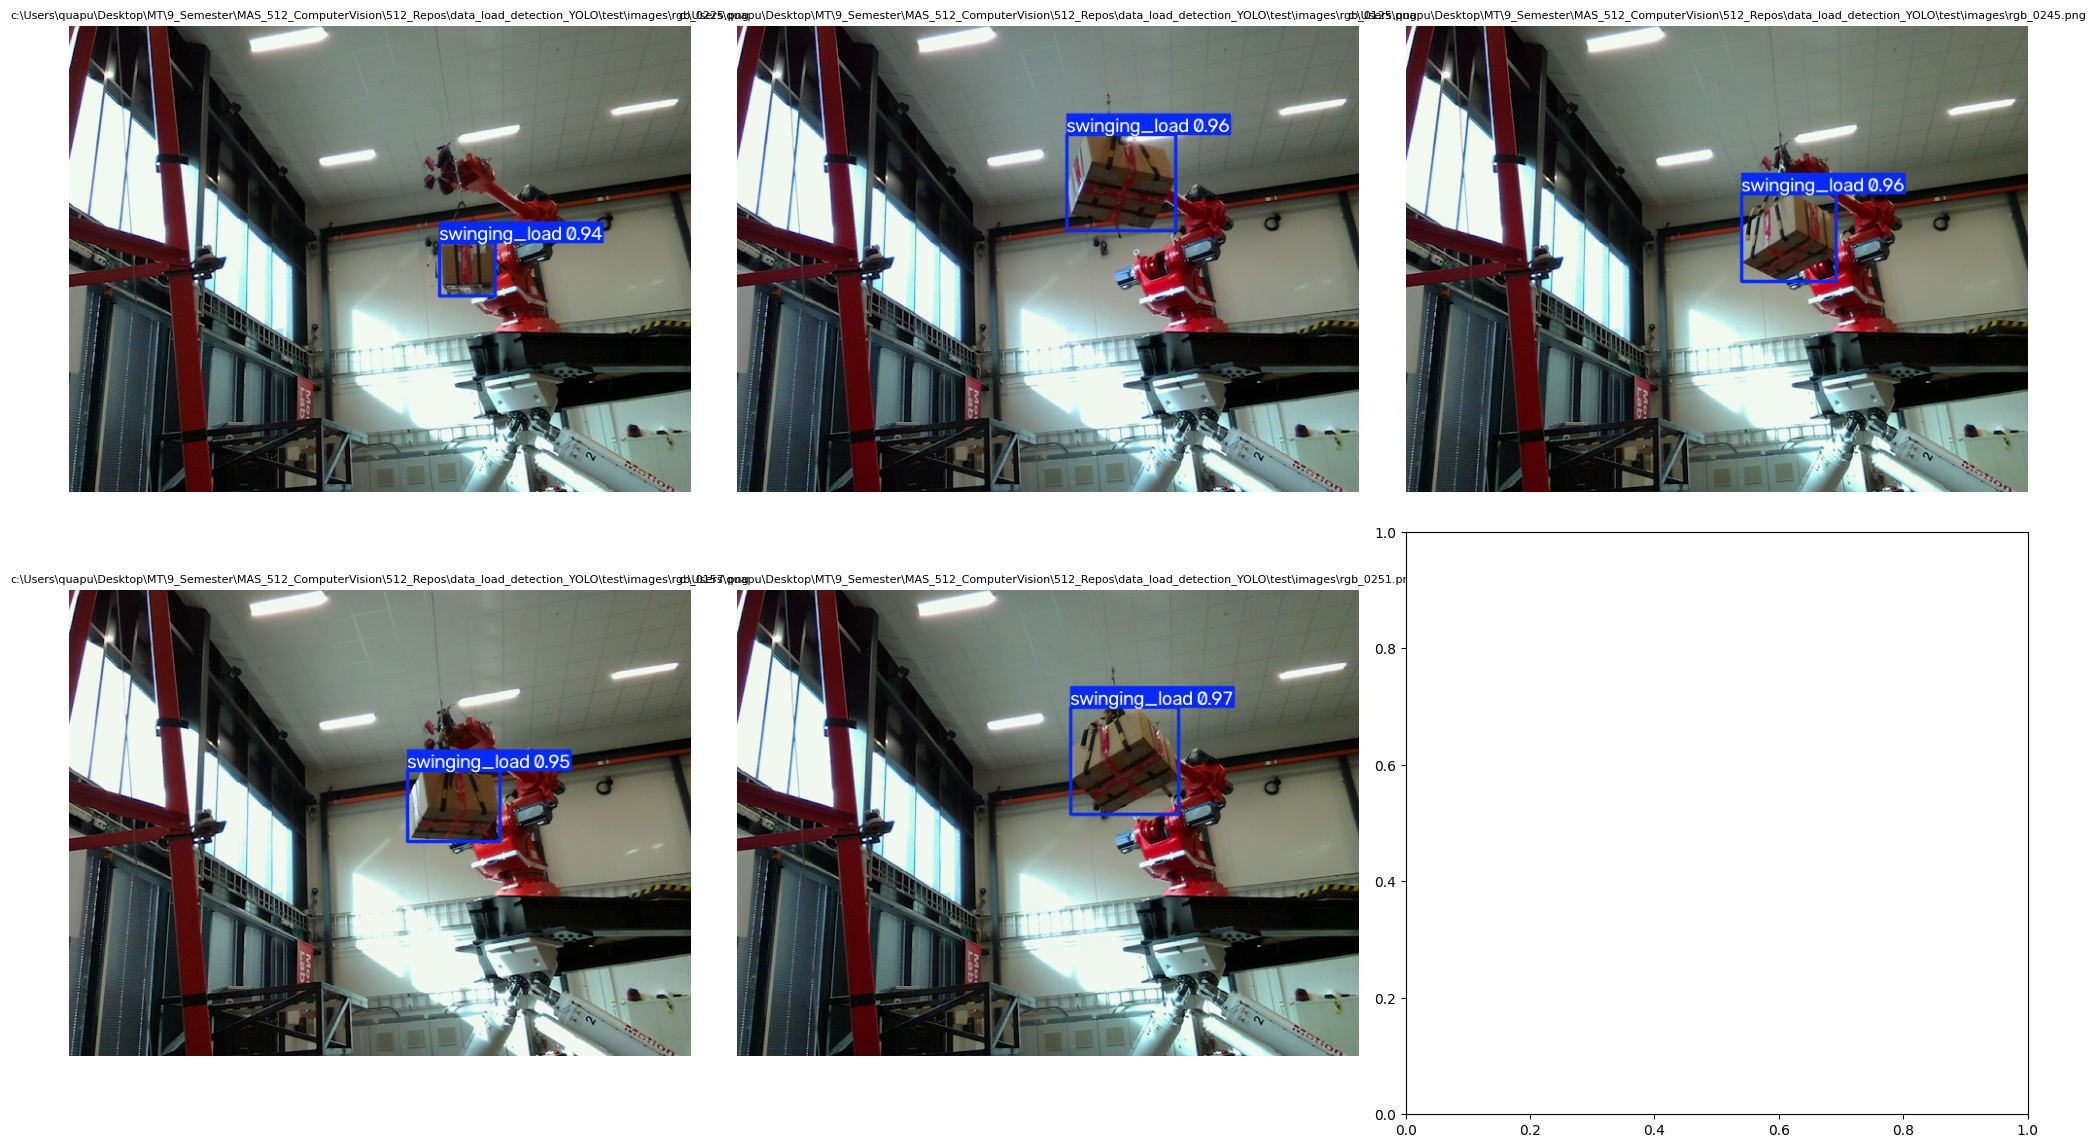

In [ ]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO

base_dir = Path("c:/Users/quapu/Desktop/MT/9_Semester/MAS_512_ComputerVision/512_Repos")
model_path = base_dir / "MAS512-Assignment1" / "Assignment 1" / "best.pt"
image_path = base_dir / "data_load_detection_YOLO" / "test" / "images"

model = YOLO(str(model_path))

all_images = list(image_path.iterdir())
selected_images = random.sample(all_images, min(5, 300))

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

for i, img_name in enumerate(selected_images):
    results = model(img_name)
    res_plotted = results[0].plot()
    res_rgb = res_plotted[..., ::-1]    # OpenCV BGR to RGB

    axes_flat[i].imshow(res_rgb)
    axes_flat[i].set_title(img_name, fontsize=8)
    axes_flat[i].axis("off")

plt.tight_layout()
plt.show()


image 1/1 c:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\data\session_20260918_152832_test\rgb_frames\rgb_0195.png: 480x640 1 swinging_load, 55.4ms
Speed: 2.0ms preprocess, 55.4ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 c:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\data\session_20260918_152832_test\rgb_frames\rgb_0110.png: 480x640 1 swinging_load, 61.2ms
Speed: 3.3ms preprocess, 61.2ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 c:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\data\session_20260918_152832_test\rgb_frames\rgb_0295.png: 480x640 1 swinging_load, 49.1ms
Speed: 2.2ms preprocess, 49.1ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 c:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\data\session_20260918_152832_test\rgb_frames\rgb_0016.png: 480x640 1 swinging_load, 46.7ms
Speed: 1.5ms preproce

c:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\venvCam\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\venvCam\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


image 1/1 c:\Users\quapu\Desktop\MT\9_Semester\MAS_512_ComputerVision\512_Repos\data\session_20260918_152832_test\rgb_frames\rgb_0059.png: 480x640 1 swinging_load, 45.2ms
Speed: 1.3ms preprocess, 45.2ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)


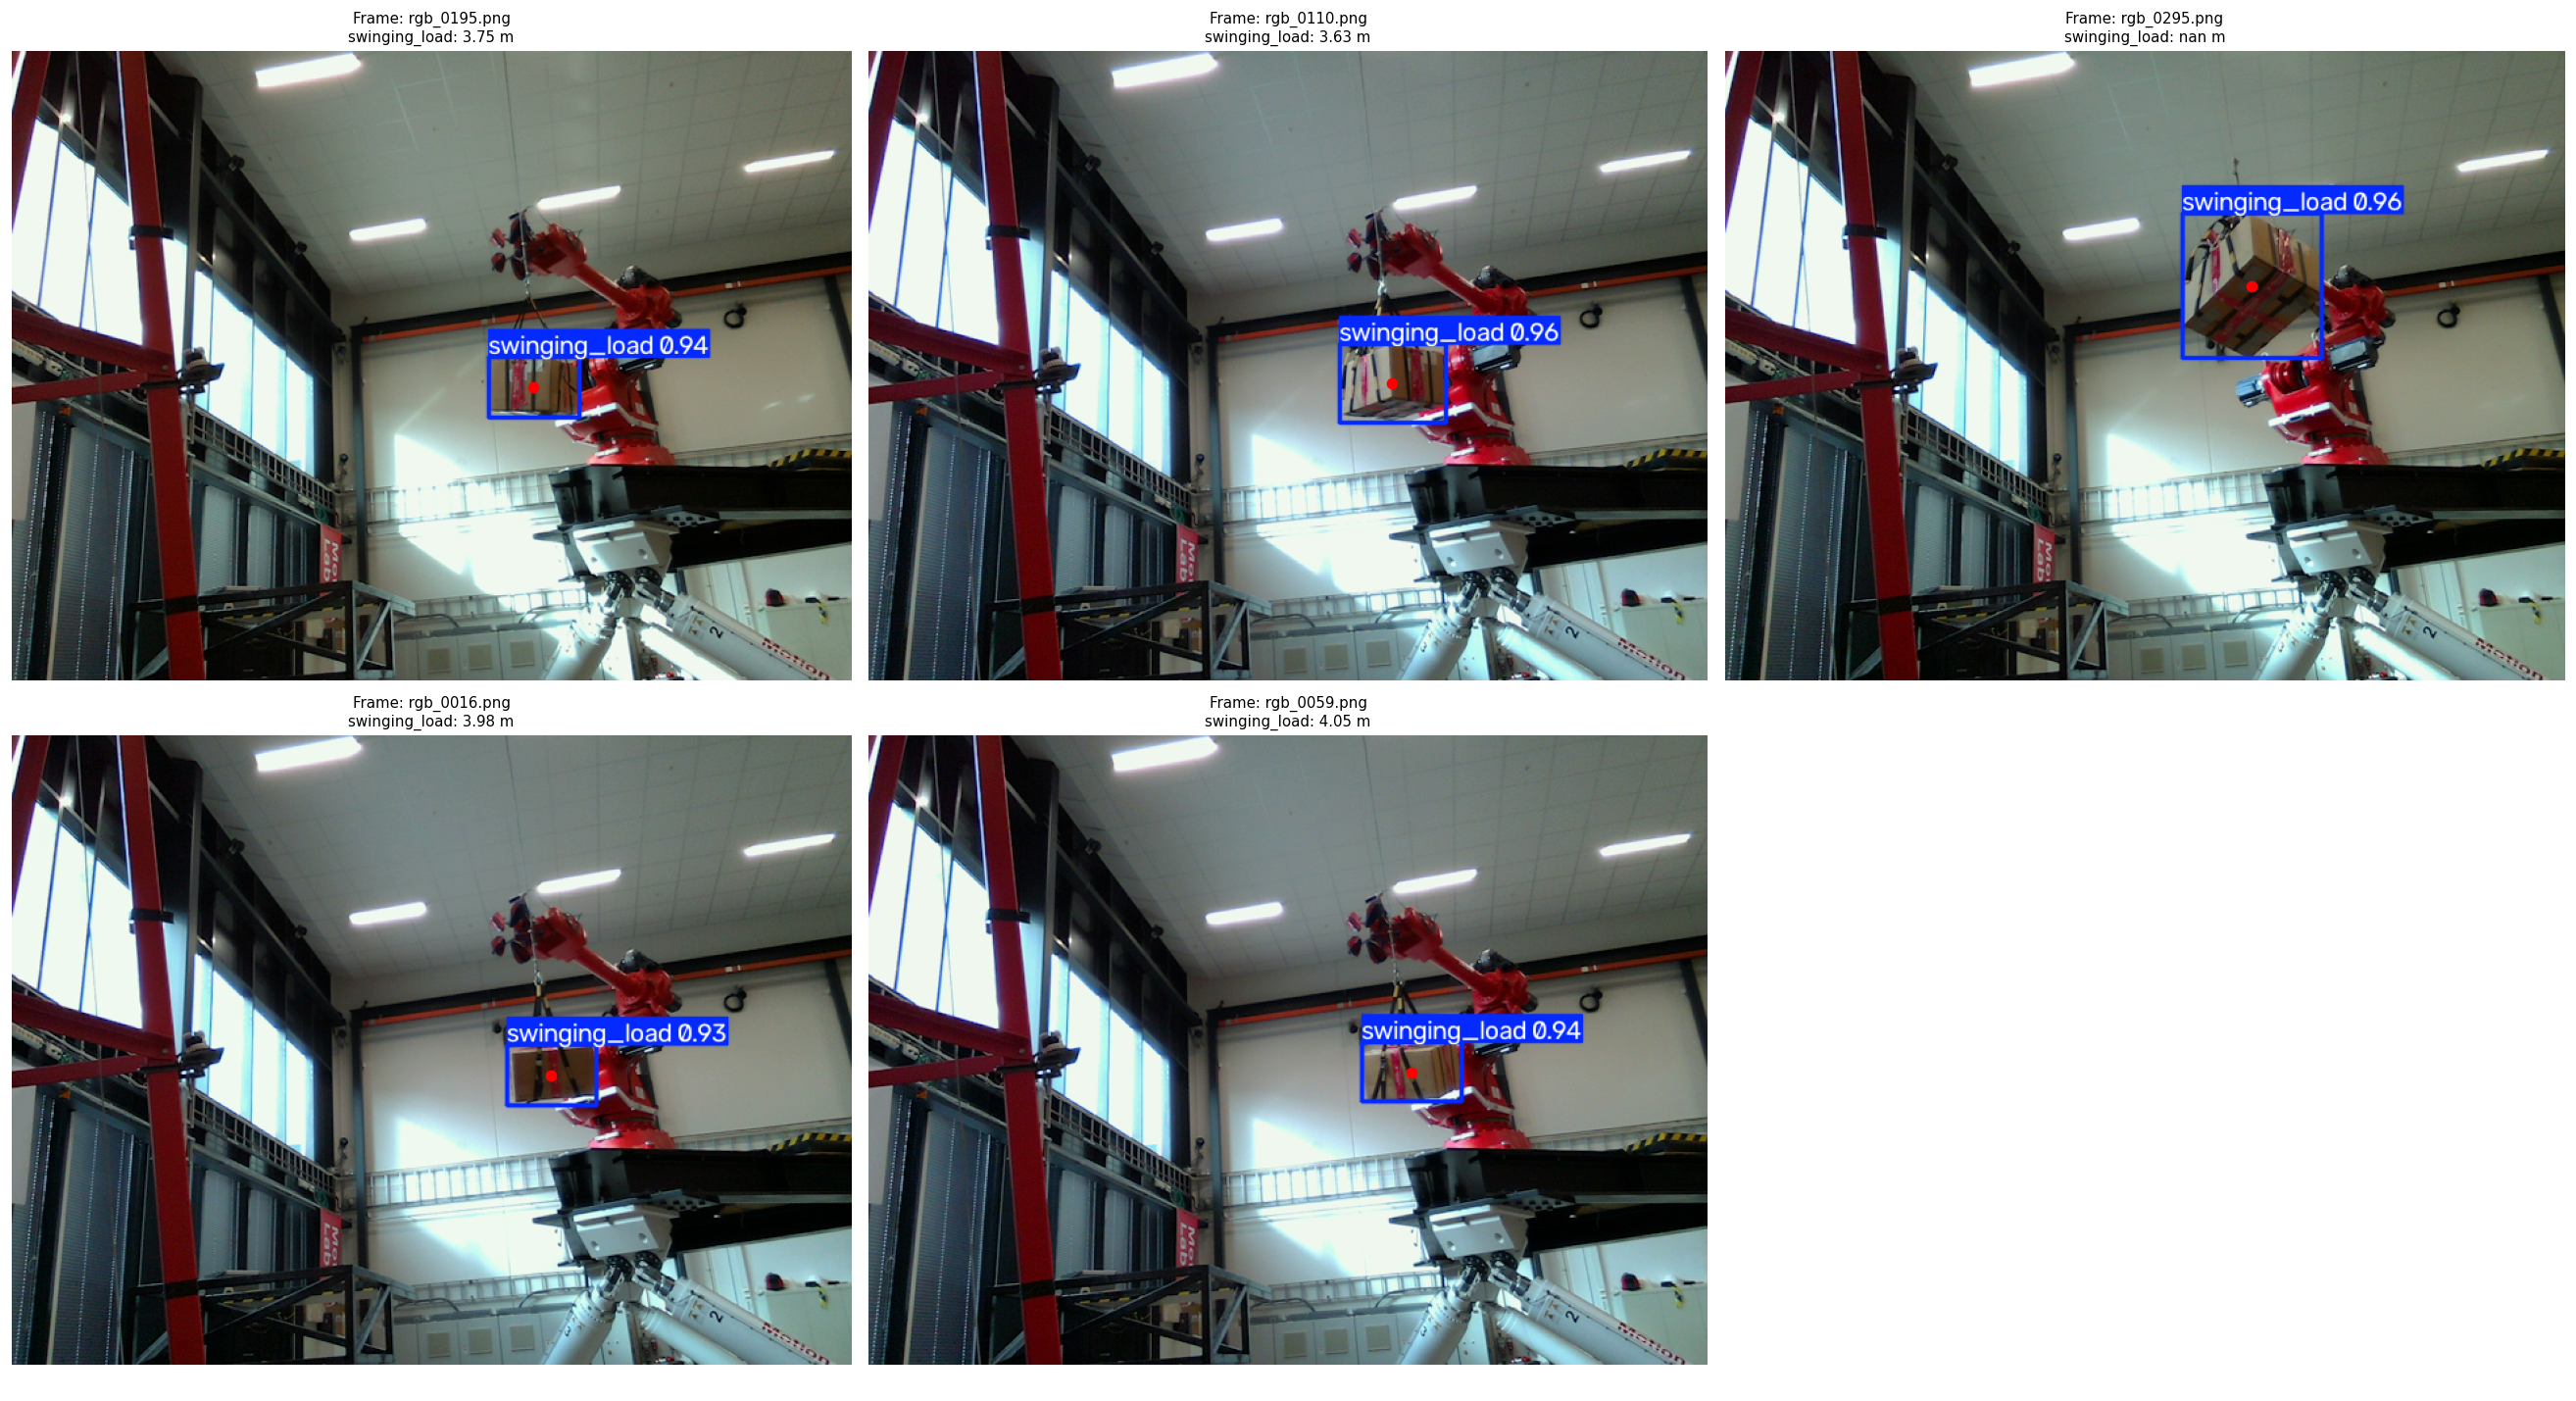

In [ ]:
import json
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

# --- PFADE KONFIGURIEREN ---
base_dir = Path("c:/Users/quapu/Desktop/MT/9_Semester/MAS_512_ComputerVision/512_Repos")
model_path = base_dir / "MAS512-Assignment1" / "Assignment 1" / "best.pt"
image_path = base_dir / "data" / "session_20260918_152832_test" / "rgb_frames"
depth_raw_path = base_dir / "data" / "session_20260918_152832_test" / "depth_raw"

# Pfad zur EINZELNEN JSON-Datei (Passe den Dateinamen an, falls er anders heißt!)
json_file = base_dir / "data" / "session_20260918_152832_test" / "depth_scale_json" / "depth_scale.json"

# Skalierungsfaktor EINMALIG vor der Schleife einlesen
with open(json_file, "r") as f:
    scale_factor = json.load(f)["depth_scale"]

model = YOLO(model_path)
selected_images = random.sample(list(image_path.iterdir()), 5)

fig, axes = plt.subplots(2, 3, figsize=(22, 12), dpi=120)
axes_flat = axes.flatten()

for i, img_file in enumerate(selected_images):
    results = model(img_file)[0]
    
    # Nur noch den Pfad zur .npy-Datei generieren
    stem = img_file.stem
    depth_file = depth_raw_path / f"{stem.replace('rgb_', 'depth_')}_raw.npy"
    depth_data = np.load(depth_file)

    ax = axes_flat[i]
    ax.imshow(results.plot()[..., ::-1])
    caption_lines = [f"Frame: {img_file.name}"]

    boxes = results.boxes.xyxy.cpu().numpy()
    clss = results.boxes.cls.cpu().numpy()

    # get depthinfo for surroundings of center for possible missing depth values
    for box, cls in zip(boxes, clss):
        x1, y1, x2, y2 = box
        cx, cy = int((x1 + x2) / 2), int((y1 + y2) / 2)

        ax.plot(cx, cy, "ro", markersize=6, zorder=5)

        window_size = 3
        depth_patch = depth_data[cy - window_size : cy + window_size + 1, cx - window_size : cx + window_size + 1]

        # calc median of center surroundings
        real_depth = np.median(depth_patch[depth_patch > 0]) * scale_factor
        caption_lines.append(f"{results.names[int(cls)]}: {real_depth:.2f} m")

    ax.axis("off")
    ax.set_title("\n".join(caption_lines), fontsize=9, loc="center")

axes_flat[5].axis("off")
plt.tight_layout()
plt.show()

# **Q2. Object tracking                                                           5 points**
  Perform tracking of swinging load on test_swingingload.avi. You should display the trajectory of load as it swings each frame as shown in Fig. below. 

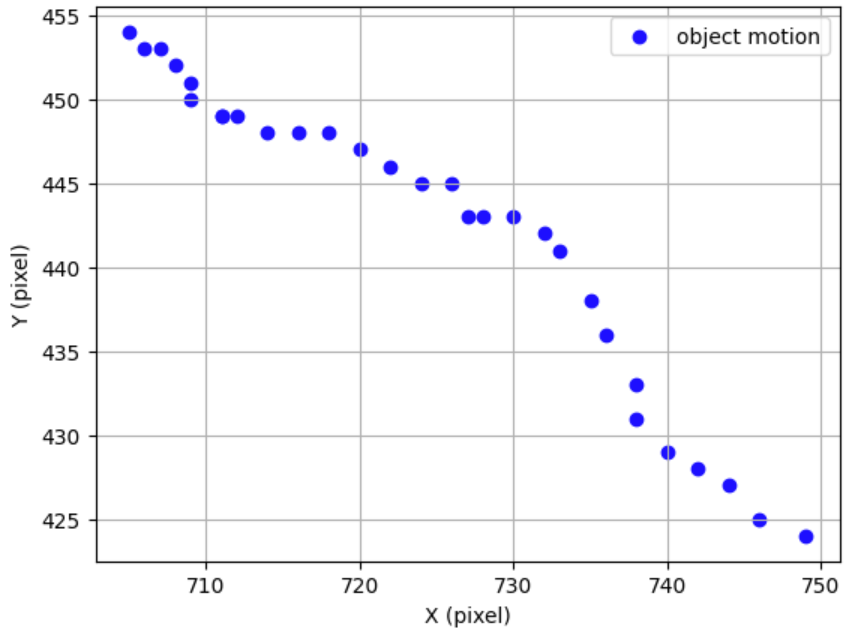

Ref: Use help from Ultralytics - https://docs.ultralytics.com/guides/instance-segmentation-and-tracking 


In [ ]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model_path = Path("best.pt")
video_path = Path("test_swingingload.avi")

assert model_path.exists(), f"Model not found: {model_path}"
assert video_path.exists(), f"Test video not found: {video_path}"

model = YOLO(str(model_path))
cap = cv2.VideoCapture(str(video_path))

centers_x, centers_y = [], []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, verbose=False)[0]

    if results.boxes is not None and len(results.boxes) > 0:
        x1, y1, x2, y2 = results.boxes.xyxy[0].cpu().numpy()
        centers_x.append((x1 + x2) / 2)
        centers_y.append((y1 + y2) / 2)

cap.release()
print(f"Object detected and tracked in {len(centers_x)} frames.")

plt.figure(figsize=(8, 6))
plt.scatter(centers_x, centers_y, color="blue", label="object motion")
plt.xlabel("X (pixel)")
plt.ylabel("Y (pixel)")
plt.title("Q2 - Swinging Load Trajectory")
plt.legend()
plt.grid(True)
plt.show()


# **Q3. Multi object segmentation, tracking and counting:                         10  points**

Explore different data-set available freely on internet (https://docs.ultralytics.com/datasets ). Get familiar with them. Then choose a data set and corresponding class of your choice (e.g. CIFAR-10, dataset/COCO data set or KITTI data set / person). Then make a video such that multiple instances of objects are in the scene (e.g. 5 people are the scene). Perform 
(a) instance segmentation, 
(b) counting  - total number of object in scene
(c) and tracking of individual instance of object
(d) draw a region - and count the object in that region


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from ultralytics.utils.plotting import colors, Annotator

cap = cv2.VideoCapture("street.mp4")
model = YOLO("yolo11n-seg.pt")
names = model.names

#(d) Define the Region of Interest (ROI)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

roi_points = np.array([
    [int(width * 0.2), int(height * 0.3)],
    [int(width * 0.8), int(height * 0.3)],
    [int(width * 0.8), int(height * 0.8)],
    [int(width * 0.2), int(height * 0.8)]
], np.int32)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True)[0] #(c) Tracking of individual instance
    annotator = Annotator(frame)

    #Per-frame count variables
    total_count = 0
    roi_count = 0

    if results.boxes.id is not None and results.masks is not None:
        boxes = results.boxes.xyxy.tolist()
        Track_ID = results.boxes.id.int().tolist()
        Class_ID = results.boxes.cls.int().tolist()  #Converted directly to int to avoid type issues
        masks = results.masks

        total_count = len(Track_ID)
        annotator.masks(masks=masks.data, colors=[colors(int(x), True) for x in (Track_ID)]) #(a) Draw segmentation masks

        #for drawing the bounding boxes
        for b, t, c in zip(boxes, Track_ID, Class_ID):
            x1, y1, x2, y2 = b
            center_x = int((x1 + x2) / 2)
            center_y = int((y1 + y2) / 2)

            #(d) Check if the center of the object is within the ROI
            is_inside = cv2.pointPolygonTest(roi_points, (center_x, center_y), False) >= 0
            if is_inside:
                roi_count += 1

            label_text = f"ID: {t} {names[c]}"
            annotator.box_label(b, color=colors(t, True), label=names[c])

            cv2.circle(frame, (center_x, center_y), 4, (0, 255, 255), -1)

    cv2.polylines(frame, [roi_points], isClosed=True, color=(255, 255, 0), thickness=3)
    cv2.putText(frame, f"Total Objects: {total_count}", (30, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2) #(b) Show Total Count
    cv2.putText(frame, f"Objects in ROI: {roi_count}", (30, 80), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
    
    cv2.imshow("Image segmentation", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()



0: 384x640 2 persons, 1 truck, 70.2ms
Speed: 3.5ms preprocess, 70.2ms inference, 10.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1 truck, 72.0ms
Speed: 3.6ms preprocess, 72.0ms inference, 8.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1 truck, 61.9ms
Speed: 3.6ms preprocess, 61.9ms inference, 9.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 truck, 64.4ms
Speed: 2.8ms preprocess, 64.4ms inference, 9.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 truck, 64.2ms
Speed: 3.2ms preprocess, 64.2ms inference, 8.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 truck, 66.4ms
Speed: 4.5ms preprocess, 66.4ms inference, 6.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 car, 1 truck, 80.1ms
Speed: 5.2ms preprocess, 80.1ms inference, 7.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 car, 1 truck, 64.4ms

# **Q4. Classification                                                        10  marks**
Given the data-set fault-classification-class. Perform the following
(a) Develop ML model to determine the state of health of asset (in this case motor).
(b) Show, train and val loss, confusion matrix and classification report
(c) Consider the one in the class as baseline and compare your model with it. Summarize in terms of
model parameter, inference time, accuracy, precision, recall, F1 score


In [ ]:
import time
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Data

DATA_DIR = Path("fault-classification-class")
CLASSES = {"00_15": 0, "10_15": 1}
TRAIN_ID_CUTOFF = 144  # 80% of 180


def load_images(split_dir, id_range=None):
    images, labels = [], []
    for class_name, label in CLASSES.items():
        for f in (split_dir / class_name).glob("*.png"):
            if id_range is not None:
                measurement_no = int(f.stem.split("_")[2].replace("Cropped", ""))
                if not (id_range[0] <= measurement_no <= id_range[1]):
                    continue
            images.append(np.array(Image.open(f).convert("RGB"), dtype=np.float32))
            labels.append(label)
    return np.stack(images), np.array(labels)


train_dir = DATA_DIR / "training"
test_dir = DATA_DIR / "testing"

X_train, y_train = load_images(train_dir, id_range=(1, TRAIN_ID_CUTOFF))
X_val, y_val = load_images(train_dir, id_range=(TRAIN_ID_CUTOFF + 1, 180))
X_test, y_test = load_images(test_dir)

y_train_cat = to_categorical(y_train, 2)
y_val_cat = to_categorical(y_val, 2)
y_test_cat = to_categorical(y_test, 2)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Eval

CLASS_NAMES = ["Healthy (00_15)", "Faulty (10_15)"]


def plot_loss_curve(history, model_name):
    plt.figure(figsize=(6, 4))
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


def evaluate_classifier(model, X_test, y_test, model_name):
    start = time.time()
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    inference_time_ms = (time.time() - start) / len(X_test) * 1000

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=CLASS_NAMES, cmap="Blues", colorbar=False, ax=axes[0]
    )
    axes[0].set_title("Counts")
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=CLASS_NAMES, cmap="Blues", colorbar=False,
        normalize="true", ax=axes[1]
    )
    axes[1].set_title("Normalized")
    plt.suptitle(model_name)
    plt.tight_layout()
    plt.show()

    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted")
    return {
        "Model": model_name,
        "Parameters": model.count_params(),
        "Inference time (ms/img)": round(inference_time_ms, 3),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
    }

#AI: Architcture Display

def draw_architecture_diagram(model, title, save_path=None):
    """Block diagram of a model's layers (type + output shape), same style as class slides."""
    layer_style = {
        "InputLayer": ("Input", "#8ecae6"), "Rescaling": ("Normalize", "#4361ee"),
        "Conv2D": ("Conv2D", "#f9c74f"), "BatchNormalization": ("BatchNorm", "#c77dff"),
        "MaxPooling2D": ("MaxPool", "#f9844a"), "ReLU": ("ReLU", "#f94144"),
        "GlobalAveragePooling2D": ("GlobalAvgPool", "#b5838d"), "Flatten": ("Flatten", "#b5838d"),
        "Dense": ("Dense", "#90be6d"), "Dropout": ("Dropout", "#a2d2ff"),
    }
    fig, ax = plt.subplots(figsize=(max(12, len(model.layers) * 1.3), 4))
    x = 0
    for i, layer in enumerate(model.layers):
        label, color = layer_style.get(layer.__class__.__name__, (layer.__class__.__name__, "#adb5bd"))
        shape = "x".join(str(d) for d in layer.output.shape[1:])
        ax.add_patch(mpatches.FancyBboxPatch((x, 0), 1, 2, boxstyle="round,pad=0.02",
                                              edgecolor="black", facecolor=color))
        ax.text(x + 0.5, 1, label, ha="center", va="center", rotation=90, fontsize=9)
        ax.text(x + 0.5, 2.15 if i % 2 == 0 else -0.15, shape, ha="center",
                va="bottom" if i % 2 == 0 else "top", fontsize=8)
        x += 1.35
    ax.set_xlim(-0.35, x)
    ax.set_ylim(-1, 3)
    ax.axis("off")
    ax.set_title(title, fontsize=13, pad=25)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# Model 1 - Custom CNN

inputs = layers.Input(shape=(60, 175, 3))
x = layers.Rescaling(1.0 / 255)(inputs)
for filters in (16, 32, 64):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation="softmax")(x)

model_1 = models.Model(inputs, outputs, name="model_1_custom")
model_1.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model_1.summary()
draw_architecture_diagram(model_1, "Model 1 (custom)", save_path="model_1_architecture.png")

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
start_time = time.time()
history_model_1 = model_1.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat),
                               epochs=20, batch_size=32, callbacks=[early_stop])
print(f"Training time model 1: {time.time() - start_time:.2f} s")

plot_loss_curve(history_model_1, "Model 1 (custom)")
metrics_model_1 = evaluate_classifier(model_1, X_test, y_test, "Model 1 (custom)")

#Model 2 - given; See PDF from Canvas

inputs = layers.Input(shape=(60, 175, 3))
x = layers.Rescaling(1.0 / 255)(inputs)
for filters in (8, 16, 64, 64, 64):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.ReLU()(x)
x = layers.Flatten()(x)
x = layers.Dense(64)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation="softmax")(x)

model_2 = models.Model(inputs, outputs, name="model_2_given")
model_2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model_2.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
start_time = time.time()
history_model_2 = model_2.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat),
                               epochs=20, batch_size=32, callbacks=[early_stop])
print(f"Training time model 2: {time.time() - start_time:.2f} s")

plot_loss_curve(history_model_2, "Model 2 (given baseline)")
metrics_model_2 = evaluate_classifier(model_2, X_test, y_test, "Model 2 (given baseline)")

#Comparison

df_compare = pd.DataFrame([metrics_model_1, metrics_model_2])
display(df_compare)


# **Q5. Classification                                                        20 marks**  
Download CFAR-10 dataset (https://www.tensorflow.org/datasets/catalog/cifar10). Perform the classification task on this dataset 
(a) Use model fusion (use two or models to extract feature and combine them), 
(b) Use transfer learning
(c) Use finetuning
(d) Compare different methods (a) - (c) in terms of typical KPIs often used for classification


**MODEL FUSION:**

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import numpy as np
import pickle
import matplotlib.pyplot as plt

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

folder_path = 'cifar-10-batches-py/'
X_train_list = []
y_train_list = []

for i in range(1,6):
    file_path = folder_path + f'data_batch_{i}'
    batch = unpickle(file_path)
    X_train_list.append(batch[b'data'])
    y_train_list.extend(batch[b'labels'])

X_train = np.vstack(X_train_list)
y_train = np.array(y_train_list)

test_path = folder_path + 'test_batch'
test_batch = unpickle(test_path)
# 'data' contains the images broken down into vectors of 3,072 values ​​(32x32x3)
X_test = test_batch[b'data']
y_test = np.array(test_batch[b'labels'])

# Format as an image (32x32 px, 3 RGB channels)
X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

#Easy way to load the CIFAR-10 dataset BUT it took 30min to download
#(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
from tensorflow.keras.applications import MobileNetV2, ResNet50V2
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping


inputs = tf.keras.Input(shape=(32, 32, 3))
x = layers.Resizing(64, 64)(inputs)

base_a = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3) # Recommended internal dimension for MobileNet
)
base_a.trainable = False

base_b = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3) # Recommended internal dimension for ResNet50V2
)
base_b.trainable = False

#Extract feature vectors from both models
feat_a = layers.GlobalAveragePooling2D()(base_a(x, training=False))
feat_b = layers.GlobalAveragePooling2D()(base_b(x, training=False))
fused = layers.Concatenate()([feat_a, feat_b]) #Feature Fusion

x = layers.Dense(256, activation='relu', activity_regularizer=L2(0.01))(fused)
x = layers.Dropout(0.5)(x) #Dropout to reduce overfitting
predictions = layers.Dense(10, activation='softmax')(x)

model_fusion = models.Model(inputs=inputs, outputs=predictions)

model_fusion.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import time

#Training with Early Stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=2, 
    restore_best_weights=True
)

start_time = time.time()

history_fusion = model_fusion.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

time_tl = time.time() - start_time
print(f"Training Time Model Fusion: {time_tl:.2f} seconds")

Epoch 1/10
313/313 [==============================] - 131s 408ms/step - loss: 1.6455 - accuracy: 0.5643 - val_loss: 1.2837 - val_accuracy: 0.6904
Epoch 2/10
313/313 [==============================] - 139s 445ms/step - loss: 1.3032 - accuracy: 0.6687 - val_loss: 1.1735 - val_accuracy: 0.7019
Epoch 3/10
313/313 [==============================] - 143s 458ms/step - loss: 1.1900 - accuracy: 0.6993 - val_loss: 1.1444 - val_accuracy: 0.7084
Epoch 4/10
313/313 [==============================] - 141s 451ms/step - loss: 1.1194 - accuracy: 0.7167 - val_loss: 1.1224 - val_accuracy: 0.7050
Epoch 5/10
313/313 [==============================] - 153s 488ms/step - loss: 1.0651 - accuracy: 0.7291 - val_loss: 1.1230 - val_accuracy: 0.7011
Epoch 6/10
313/313 [==============================] - 177s 566ms/step - loss: 1.0204 - accuracy: 0.7443 - val_loss: 1.1128 - val_accuracy: 0.7012
Epoch 7/10
313/313 [==============================] - 144s 462ms/step - loss: 0.9810 - accuracy: 0.7544 - val_loss: 1.1193 -

**TRANSFER LEARNING:**

In [ ]:
inputs = tf.keras.Input(shape=(32, 32, 3))
x = layers.Resizing(64, 64)(inputs)

#Instead of two models, use only one (ej. MobileNetV2)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)
base_model.trainable = False  # Freeze weights

#Feature extraction
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

#Classification head with proper regularization
x = layers.Dense(256, activation='relu', kernel_regularizer=L2(0.01))(x)
x = layers.Dropout(0.5)(x)
predictions = layers.Dense(10, activation='softmax')(x)

model_tl = models.Model(inputs=inputs, outputs=predictions, name="Transfer_Learning_MobileNet")

model_tl.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Training
start_time = time.time()

history_tl = model_tl.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

time_tl = time.time() - start_time
print(f"Training Time Transfer Learning: {time_tl:.2f} seconds")
model_tl.save("transfer_learning_model.keras")

Epoch 1/10
313/313 [==============================] - 39s 120ms/step - loss: 2.4994 - accuracy: 0.5495 - val_loss: 1.4244 - val_accuracy: 0.6412
Epoch 2/10
313/313 [==============================] - 40s 128ms/step - loss: 1.4367 - accuracy: 0.6124 - val_loss: 1.2987 - val_accuracy: 0.6457
Epoch 3/10
313/313 [==============================] - 47s 150ms/step - loss: 1.3829 - accuracy: 0.6157 - val_loss: 1.2950 - val_accuracy: 0.6411
Epoch 4/10
313/313 [==============================] - 46s 148ms/step - loss: 1.3706 - accuracy: 0.6178 - val_loss: 1.2894 - val_accuracy: 0.6426
Epoch 5/10
313/313 [==============================] - 46s 147ms/step - loss: 1.3728 - accuracy: 0.6181 - val_loss: 1.2840 - val_accuracy: 0.6452
Epoch 6/10
313/313 [==============================] - 47s 149ms/step - loss: 1.3709 - accuracy: 0.6191 - val_loss: 1.3009 - val_accuracy: 0.6466
Epoch 7/10
313/313 [==============================] - 46s 148ms/step - loss: 1.3706 - accuracy: 0.6223 - val_loss: 1.2944 - val_ac

**FINE TUNING:**

In [ ]:
#Unfreeze the base model
base_model.trainable = True

#Keep the first layers frozen and thaw only the last 20 layers.
for layer in base_model.layers[:-20]:
    layer.trainable = False

#Recompile with a VERY SMALL Learning Rate
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Continue training for a few epochs
start_time = time.time()

history_ft = model_tl.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

time_ft = time.time() - start_time
print(f"Training Time Fine-Tuning: {time_ft:.2f} seconds")

Epoch 1/5
313/313 [==============================] - 78s 236ms/step - loss: 0.9310 - accuracy: 0.7544 - val_loss: 0.9942 - val_accuracy: 0.7316
Epoch 2/5
313/313 [==============================] - 72s 231ms/step - loss: 0.8959 - accuracy: 0.7667 - val_loss: 0.9799 - val_accuracy: 0.7336
Epoch 3/5
313/313 [==============================] - 72s 230ms/step - loss: 0.8645 - accuracy: 0.7766 - val_loss: 0.9669 - val_accuracy: 0.7351
Epoch 4/5
313/313 [==============================] - 72s 229ms/step - loss: 0.8344 - accuracy: 0.7853 - val_loss: 0.9620 - val_accuracy: 0.7381
Epoch 5/5
313/313 [==============================] - 71s 228ms/step - loss: 0.8029 - accuracy: 0.7918 - val_loss: 0.9449 - val_accuracy: 0.7413
Training Time Fine-Tuning: 366.15 seconds


**EVALUATE MODELS:**

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

#Code made with Gemini. Is 8pm, I'm tired.
def evaluate_model(model, X_test, y_test, model_name):
    y_true = np.argmax(y_test, axis=1)
    y_pred_probs = model.predict(X_test, batch_size=128)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Metrics calculation
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

    metrics = {
        "Model": model_name,
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4)
    }

    return metrics, y_true, y_pred

results = []

m_fusion, y_true, y_pred_fusion = evaluate_model(model_fusion, X_test, y_test, "Model Fusion")
results.append(m_fusion)

model_tl_freeze = tf.keras.models.load_model("transfer_learning_model.keras")
m_tl, _, y_pred_tl = evaluate_model(model_tl_freeze, X_test, y_test, "Transfer Learning") #I forgot to save the transfer learning so It won't be "model_tl" but "model_tl_freeze". Need to redoit again. Shit. 
results.append(m_tl)

m_ft, _, y_pred_ft = evaluate_model(model_tl, X_test, y_test, "Fine-Tuning")
results.append(m_ft)

79/79 [==============================] - 14s 161ms/step


In [12]:
df_kpis = pd.DataFrame(results)
print("=== Comparison of Classification Metrics and KPIs ===")
display(df_kpis)

=== Comparison of Classification Metrics and KPIs ===


,Model,accuracy,precision,recall,f1
0,Model Fusion,0.7020,0.7024,0.7020,0.7018
1,Transfer Learning,0.7197,0.7185,0.7197,0.7183
2,Fine-Tuning,0.7394,0.7379,0.7394,0.7376


# **Q6. Autoencoder                                                           10 marks**
Given the data-set fault-classification-class, 
Use Auto encoder to compress the data to latent space and reconstruct it back. Show the following for random 10 iamges from each class
(a) Original image
(b) Latent vector
(c) Reconstructed back image
(d) individual reconstruction error and mean loss for each class.


In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers, models

DATA_DIR = Path("fault-classification-class")
CLASSES = {"00_15": 0, "10_15": 1}


def load_images(split_dir):
    images, labels = [], []
    for class_name, label in CLASSES.items():
        for f in (split_dir / class_name).glob("*.png"):
            images.append(np.array(Image.open(f).convert("RGB"), dtype=np.float32) / 255.0)
            labels.append(label)
    return np.stack(images), np.array(labels)


X_train, y_train = load_images(DATA_DIR / "training")
X_test, y_test = load_images(DATA_DIR / "testing")

img_shape = X_train.shape[1:]
img_size = int(np.prod(img_shape))
latent_dim = 32

inputs = layers.Input(shape=img_shape)
x = layers.Flatten()(inputs)
x = layers.Dense(256, activation="relu")(x)
latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)
x = layers.Dense(256, activation="relu")(latent)
x = layers.Dense(img_size, activation="sigmoid")(x)
outputs = layers.Reshape(img_shape)(x)

autoencoder = models.Model(inputs, outputs)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

autoencoder.fit(X_train, X_train, validation_split=0.2, epochs=20, batch_size=32)

encoder = models.Model(inputs, latent)

for class_name, label in CLASSES.items():
    idx = np.where(y_test == label)[0]
    chosen = np.random.choice(idx, 10, replace=False)

    originals = X_test[chosen]
    latents = encoder.predict(originals, verbose=0)
    reconstructed = autoencoder.predict(originals, verbose=0)
    errors = np.mean((originals - reconstructed) ** 2, axis=(1, 2, 3))

    fig, axes = plt.subplots(3, 10, figsize=(20, 6))
    for i in range(10):
        axes[0, i].imshow(originals[i])
        axes[0, i].axis("off")
        axes[0, i].set_title(f"{errors[i]:.4f}", fontsize=8)
        axes[1, i].bar(range(latent_dim), latents[i])
        axes[1, i].axis("off")
        axes[2, i].imshow(reconstructed[i])
        axes[2, i].axis("off")
    fig.suptitle(f"{class_name} - mean error: {errors.mean():.4f}")
    plt.tight_layout()
    plt.show()
